# 2. Which branch moved?

**Week 1, Tuesday. Chapter 2 of 6.** By the end of this notebook you can split the quarter's fall along the revenue tree, say in rupees how much each branch carries, and answer Marketing's claim about customers with a count.

> **The client asks.** "Are we losing customers, or are the ones we have buying less? Marketing
> says more customers. Prove it or disprove it."
>
> Meera Raghavan, CEO, Kalpa Retail

**What chapter 1 established, and what this adds.** The drop is real on matched windows: two closed
quarters of thirteen weeks, Rs 2,10,00,000 to Rs 1,87,00,000, a fall of Rs 23,00,000 and 11.0 percent.
Chapter 1's tool added rupees up by quarter; this chapter grows it to count customers and orders per
customer, puts rupees on each branch of the tree, and opens the price branch, where Marketing's
monsoon discount plan lives.

> **Kavya's review of chapter 1.** "Good: you said both windows before you said a percentage. Now
> stop describing the fall and start taking it apart."

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
by_quarter = {"Q1": [], "Q2": []}           # chapter 1's accumulator, now holding the orders themselves
for order in ORDERS:
    by_quarter[order["quarter"]].append(order)
print(len(by_quarter["Q1"]), "orders in Q1 and", len(by_quarter["Q2"]), "in Q2")

114 orders in Q1 and 86 in Q2


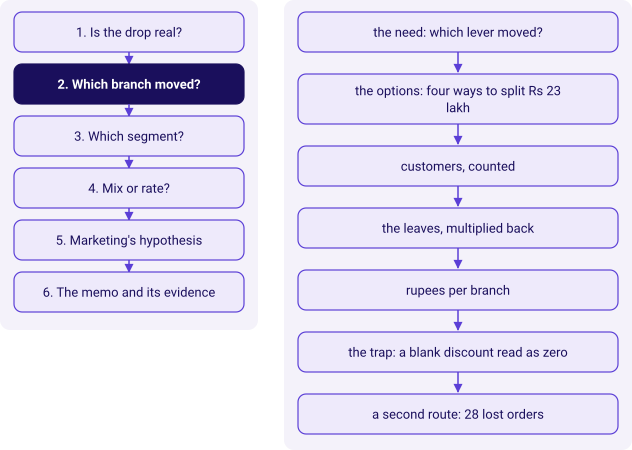

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real?', 'Which branch moved?', 'Which segment?', 'Mix or rate?', "Marketing's hypothesis", 'The memo and its evidence'], lit=1, show=False),
    kit.vflow(['the need: which lever moved?', 'the options: four ways to split Rs 23 lakh', 'customers, counted', 'the leaves, multiplied back', 'rupees per branch', 'the trap: a blank discount read as zero', 'a second route: 28 lost orders'], show=False),
)

## The need

Meera's tree has four branches: customers, how often they buy, basket, and price. Each branch has an
owner and a price tag. Customers belong to Marketing and cost acquisition spend; how often they buy
belongs to the tier and product owners and costs retention work on people already won; basket
belongs to merchandising; price and discounts belong to Finance with Marketing and trade margin for
volume. The metric at stake is the rupees each branch carries of the Rs 23,00,000 fall, and the
decision riding on it is which owner gets the problem, and whether Marketing's Rs 12 crore is aimed
at a branch that moved. A wrong split sends crores to the wrong owner for a quarter.

**Who else faces this.** Blinkit, the quick-commerce app, reports its orders and its net average
order value side by side, so its net order value can be read as the two branches of this tree: in the
fourth quarter of FY26 it reported 273.9 million orders at Rs 525 each, about Rs 14,386 crore
(Eternal, shareholders' letter, 28 April 2026, checked 30 Sep 2026). Walmart splits the growth of its
U.S. comparable sales the same way every quarter: in the quarter ended 31 July 2026, comparable sales
excluding fuel rose 2.6 percent, made of transactions up 1.5 percent and average ticket up 1.1 percent
(Walmart earnings release, second quarter of fiscal 2027, checked 30 Sep 2026). The question each
answers is Meera's: did more visits move the number, or bigger baskets?

## The options

Four ways to split the fall across the branches.

| Option | How it splits | What it gives Meera |
|---|---|---|
| A. Each leaf's percentage change | Customers, orders per customer and revenue per order, Q1 against Q2 | Direction, and no rupees, since percentages multiply and do not add |
| B. A bridge in the tree's order | Change one leaf at a time, customers first, holding the rest at Q1 | Rupees per branch that add exactly to the fall, for the order chosen |
| C. A symmetric split | Share the fall in proportion to each leaf's logarithmic change | Rupees that do not depend on any order |
| D. Customer by customer | Each of the 69 customers' Q1 and Q2 orders side by side | Who moved, at 69 rows of reading before any total |

The cell below sizes B, C and a reversed bridge on this file, since the order of the steps is where
the choice bites.

Option,Rows read,Frequency's rupees,Depends on order?
A. percentages only,200,none: percentages do not add,no
"B. bridge, tree order",200,"-Rs 51,57,895",yes
"B. bridge, order reversed",200,"-Rs 60,88,372",yes
C. symmetric split,200,"-Rs 55,88,480",no
D. customer by customer,200,"69 rows to read, then a total",no


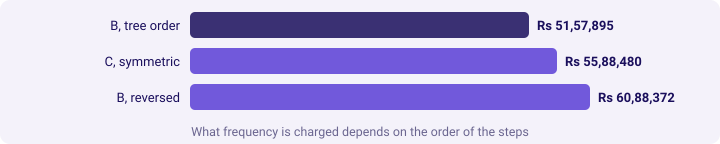

In [3]:
import math, time

def leaves(rows):
    seen = {}
    revenue = 0
    for order in rows:
        seen[order["customer_id"]] = True
        revenue += order["amount"]
    return len(seen), len(rows) / len(seen), revenue / len(rows), revenue

c1, f1, v1, r1 = leaves(by_quarter["Q1"])
c2, f2, v2, r2 = leaves(by_quarter["Q2"])
t0 = time.perf_counter()
b_freq = c2 * (f2 - f1) * v1                       # B: frequency moved before order value
b_rev = r2 - r1
rev_freq = c2 * (f2 - f1) * v2                     # B reversed: order value first, frequency second
log_mean = (r2 - r1) / math.log(r2 / r1)
c_freq = log_mean * math.log(f2 / f1)              # C: symmetric
secs = time.perf_counter() - t0
kit.table(["Option", "Rows read", "Frequency's rupees", "Depends on order?"],
          [("A. percentages only", 200, "none: percentages do not add", "no"),
           ("B. bridge, tree order", 200, kit.rupees(round(b_freq)), "yes"),
           ("B. bridge, order reversed", 200, kit.rupees(round(rev_freq)), "yes"),
           ("C. symmetric split", 200, kit.rupees(round(c_freq)), "no"),
           ("D. customer by customer", 200, "69 rows to read, then a total", "no")],
          caption=f"Sizing the split; all of it ran in {secs * 1000:.2f} ms")
kit.bars([("B, tree order", round(-b_freq)), ("C, symmetric", round(-c_freq)), ("B, reversed", round(-rev_freq))],
         fmt=kit.rupees, lit=[0], title="What frequency is charged depends on the order of the steps")
kit.check("the three rupee figures sit within Rs 10 lakh of each other", abs(rev_freq - b_freq) < 1000000,
          kit.rupees(round(abs(rev_freq - b_freq))))

**The best-fit call.** Option B, the bridge in the tree's order, because its rupees add exactly to
the fall, a CEO can follow it one step at a time, and in every order frequency carries the fall, so
the choice of order changes the size and never the decision. Write the order beside the bridge.
**The fact that would change the call:** if Finance will rebuild the split every month and two
branches keep moving together, option C removes the argument about order; if Meera asks which
customers slowed, option D is the one that names them, and chapter 5 comes back to it.

## 1. Customers held at 69 in both quarters

Marketing's claim is about the first branch, so it is counted first. A dictionary per quarter maps
each customer id to the orders that customer placed. `.get(cid, 0)` reads the count so far and
supplies 0 when the id has not appeared yet, and that default is right for a reason worth writing
down: a customer not seen yet in the quarter has placed no orders in it so far.

**Predict before you run.** How did the number of distinct customers move from Q1 to Q2? a) it fell;
b) it held; c) it rose, as Marketing says; d) it cannot be told without the segments.

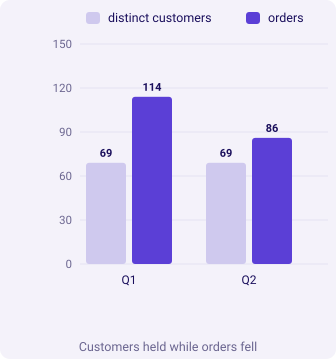

In [4]:
orders_by_customer = {"Q1": {}, "Q2": {}}      # quarter -> {customer_id: orders placed}
for q in by_quarter:
    for order in by_quarter[q]:
        cid = order["customer_id"]
        # default: a customer not seen yet in this quarter has placed zero orders in it so far
        orders_by_customer[q][cid] = orders_by_customer[q].get(cid, 0) + 1

customers = {q: len(orders_by_customer[q]) for q in by_quarter}
orders = {q: len(by_quarter[q]) for q in by_quarter}
kit.columns(["Q1", "Q2"], [("distinct customers", [customers["Q1"], customers["Q2"]]),
                           ("orders", [orders["Q1"], orders["Q2"]])],
            title="Customers held while orders fell")
kit.check("customers held at 69 in both quarters", customers["Q1"] == customers["Q2"] == 69,
          f'{customers["Q1"]} and {customers["Q2"]}')
kit.check("the per-customer counts add back to each quarter's orders",
          all(sum(orders_by_customer[q].values()) == orders[q] for q in by_quarter))

**What happened.** The answer is b. Kalpa had 69 distinct customers in each quarter, so the count
does not support "more customers". Orders fell from 114 to 86 on the same count, which already points
at the second branch. Whether the 69 are the same people is a separate question, and chapter 5 asks it.

## 2. Orders per customer carries the fall, and revenue per order rose

The tree multiplies three leaves: customers, orders per customer, and revenue per order. Price and
basket fold into revenue per order today, because the file has no order lines.

**Predict before you run.** Which leaf moved against Kalpa? a) customers; b) orders per customer;
c) revenue per order; d) all three fell a little.

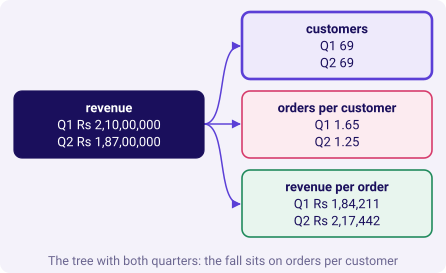

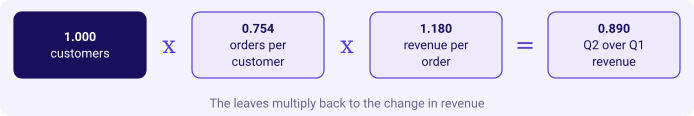

In [5]:
revenue = {"Q1": r1, "Q2": r2}
opc = {"Q1": f1, "Q2": f2}          # orders per customer
rpo = {"Q1": v1, "Q2": v2}          # revenue per order
kit.driver_tree({"label": "revenue", "note": f'Q1 {kit.rupees(r1)}\nQ2 {kit.rupees(r2)}', "kind": "lit", "children": [
    {"label": "customers", "note": f'Q1 {customers["Q1"]}\nQ2 {customers["Q2"]}', "kind": "known"},
    {"label": "orders per customer", "note": f'Q1 {f1:.2f}\nQ2 {f2:.2f}', "kind": "bad"},
    {"label": "revenue per order", "note": f'Q1 {kit.rupees(round(v1))}\nQ2 {kit.rupees(round(v2))}', "kind": "good"}]},
    title="The tree with both quarters: the fall sits on orders per customer", width_per=190)
ratio_c, ratio_f, ratio_v = c2 / c1, f2 / f1, v2 / v1
kit.equation([f"{ratio_c:.3f}\ncustomers", "x", f"{ratio_f:.3f}\norders per customer", "x",
              f"{ratio_v:.3f}\nrevenue per order", "=", f"{ratio_c * ratio_f * ratio_v:.3f}\nQ2 over Q1 revenue"],
             title="The leaves multiply back to the change in revenue")
kit.check("the three ratios multiply to Q2 over Q1 revenue", abs(ratio_c * ratio_f * ratio_v - r2 / r1) < 1e-9,
          f"{ratio_c * ratio_f * ratio_v:.3f}")
kit.check("orders per customer fell 24.6 percent and revenue per order rose 18.0",
          (round((ratio_f - 1) * 100, 1), round((ratio_v - 1) * 100, 1)) == (-24.6, 18.0))

**What happened.** The answer is b. Orders per customer fell from 1.65 to 1.25, down 24.6 percent,
while revenue per order rose 18.0 percent, from Rs 1,84,211 to Rs 2,17,442. The same count of
customers placed fewer orders, and the orders they placed were larger on average. Adding the two
percentages would say minus 6.6 percent; multiplying says 0.754 times 1.180, which is 0.890, the
11.0 percent fall. Chapter 4 asks why the orders got larger.

## 3. In rupees, frequency costs Rs 51,57,895 and bigger orders give back Rs 28,57,895

Option B, built. The bridge changes one leaf at a time in the order of the tree: first customers,
holding the other two at Q1; then orders per customer; then revenue per order.

**Predict before you run.** How many rupees does the fall in orders per customer take away?
a) Rs 23,00,000; b) Rs 51,57,895; c) Rs 28,57,895; d) nothing, because customers held.

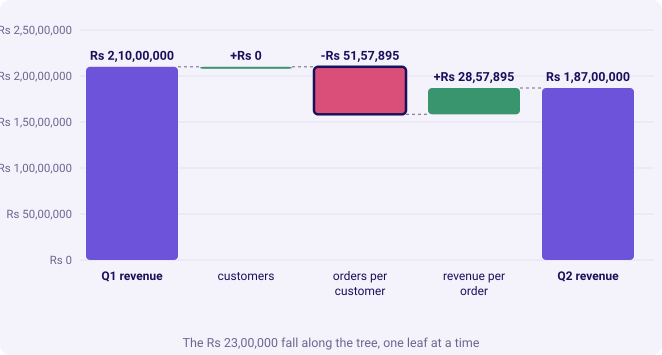

In [6]:
move_customers = (c2 - c1) * f1 * v1
move_frequency = c2 * (f2 - f1) * v1
move_order_value = c2 * f2 * (v2 - v1)
kit.bridge(("Q1 revenue", r1),
           [("customers", round(move_customers)), ("orders per customer", round(move_frequency)),
            ("revenue per order", round(move_order_value))],
           end_label="Q2 revenue", lit=[1], title="The Rs 23,00,000 fall along the tree, one leaf at a time")
kit.check("the bridge lands on Q2 revenue", abs(r1 + move_customers + move_frequency + move_order_value - r2) < 1,
          kit.rupees(r2))
kit.check("the customers move is zero", move_customers == 0)

**What happened.** The answer is b. Holding customers and order value at Q1, the fall in orders per
customer takes away Rs 51,57,895, and larger orders give back Rs 28,57,895. The customer branch
contributes nothing, so Marketing's case for acquisition has no rupees behind it on this file.

## 4. The trap: the price branch, read the hurried way

Meera's fourth branch is price, and Marketing's monsoon plan starts from one number on it: the share
of orders that carry a discount. If half the orders go without one, they want the discount extended
to the other half. The export carries a `discount` field in rupees, so the first attempt counts the
orders where it is above zero.

In [7]:
with kit.expect_error() as err:
    with_discount = 0
    for order in ORDERS:
        if order["discount"] > 0:
            with_discount += 1
kit.check("the loop stopped on a missing key", err.name == "KeyError", f"{err.name}: {err.message}")

That is a runtime error, and it takes two minutes: some records carry no `discount` key at all, and
indexing a dictionary with a key it lacks raises `KeyError`. A `try` and `except KeyError` around the
line would also get past it. The question that matters is what a missing discount means.

**Predict before you run.** A hurried analyst reads every missing discount as zero. What share of
Q2's 86 orders will carry a discount? a) about a quarter; b) about half; c) about seven in ten;
d) every order.

**The plausible wrong answer.** `.get("discount", 0)` makes the error go away and gives a number.

In [8]:
with_disc = {"Q1": 0, "Q2": 0}
for q in by_quarter:
    for order in by_quarter[q]:
        if order.get("discount", 0) > 0:          # the hurried default: missing becomes zero
            with_disc[q] += 1
as_zero_share = {q: with_disc[q] / orders[q] * 100 for q in by_quarter}
kit.stats([(f'{as_zero_share["Q1"]:.1f}%', "orders with a discount, Q1", "missing read as zero"),
           (f'{as_zero_share["Q2"]:.1f}%', "orders with a discount, Q2", "missing read as zero"),
           (f'{orders["Q2"] - with_disc["Q2"]} of {orders["Q2"]}', "Q2 orders read as no discount", "so, extend it to them?")])

**Why it is wrong.** The answer to the prediction is b, and it is the wrong number. The 43 Q2 orders
the hurried reading files under "no discount" are two different things: orders where someone
recorded Rs 0 off, and orders where nobody wrote the discount down at all. The second kind is
unknown, and a default of zero counts every one of them as an order that went without. The decision
it misleads is expensive: Marketing extends the monsoon discount to "the other half" of orders,
spending margin on orders that may already carry one.

The mechanism on three **invented** orders, one with Rs 100 off, one with Rs 0 off, and one with no
field at all:

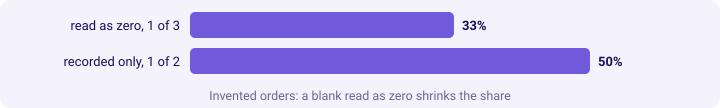

In [9]:
invented = [{"order_id": "INVENTED-1", "discount": 100},
            {"order_id": "INVENTED-2", "discount": 0},
            {"order_id": "INVENTED-3"}]                      # invented records, no discount field on the third
as_zero_with = sum(1 for o in invented if o.get("discount", 0) > 0)
recorded = [o for o in invented if "discount" in o]
recorded_with = sum(1 for o in recorded if o["discount"] > 0)
kit.bars([("read as zero, 1 of 3", round(as_zero_with / 3 * 100)), ("recorded only, 1 of 2", round(recorded_with / len(recorded) * 100))],
         fmt=lambda v: f"{v}%", title="Invented orders: a blank read as zero shrinks the share")
kit.check("on the invented orders, read-as-zero gives 33 percent and recorded-only 50 percent",
          (round(as_zero_with / 3 * 100), round(recorded_with / len(recorded) * 100)) == (33, 50))

**Your turn.** Count the Kalpa records that carry no `discount` field, in each quarter. Type these
lines into the empty cell below and run them, then say in one sentence how many of the orders the
hurried reading called "no discount" were never recorded:

```python
missing = {"Q1": 0, "Q2": 0}
for order in ORDERS:
    if "discount" not in order:
        missing[order["quarter"]] += 1
print(missing)
```

**The check.** Split the orders the hurried reading called "no discount" into the ones that record
Rs 0 and the ones with no field at all, and find the largest discount anyone recorded.

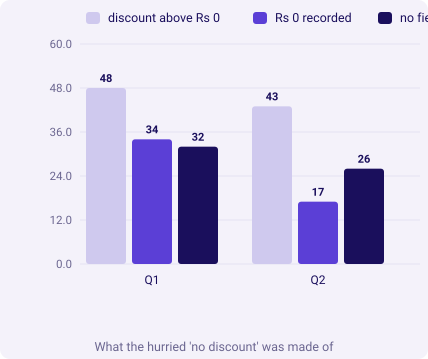

In [10]:
kinds = {q: {"above": 0, "zero": 0, "blank": 0} for q in by_quarter}
largest = 0
for q in by_quarter:
    for order in by_quarter[q]:
        if "discount" not in order:
            kinds[q]["blank"] += 1
        elif order["discount"] > 0:
            kinds[q]["above"] += 1
            largest = max(largest, order["discount"])
        else:
            kinds[q]["zero"] += 1
kit.columns(["Q1", "Q2"], [("discount above Rs 0", [kinds["Q1"]["above"], kinds["Q2"]["above"]]),
                           ("Rs 0 recorded", [kinds["Q1"]["zero"], kinds["Q2"]["zero"]]),
                           ("no field", [kinds["Q1"]["blank"], kinds["Q2"]["blank"]])],
            fmt=lambda v: f"{v}", title="What the hurried 'no discount' was made of")
kit.check("the three kinds add up to every order in each quarter", all(sum(kinds[q].values()) == orders[q] for q in kinds))
kit.check("Q2's 'no discount' orders are recorded zeros plus blanks",
          orders["Q2"] - with_disc["Q2"] == kinds["Q2"]["zero"] + kinds["Q2"]["blank"],
          f'{orders["Q2"] - with_disc["Q2"]} = {kinds["Q2"]["zero"]} + {kinds["Q2"]["blank"]}')
kit.check("the largest recorded discount is Rs 150", largest == 150, kit.rupees(largest))

**The fix.** Treat a blank as unknown. Write the rule where the next person will read it, report
the share over the orders that record the field, give the range the blanks allow, and bound the
branch in rupees: the largest recorded discount is Rs 150, so even if every one of Q2's 86 orders had
carried Rs 150 off, the branch could hold at most Rs 12,900 against a fall of Rs 23,00,000.

Share of orders with a discount,Q1,Q2
hurried: blanks read as zero,42.1%,50.0%
over the orders that record the field,58.5% of 82,71.7% of 60
"range over all orders, blanks unknown",42.1% to 70.2%,50.0% to 80.2%


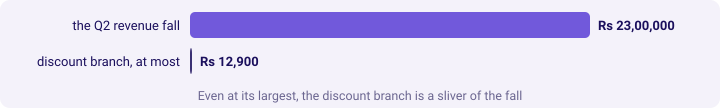

The rule, written down: absent means not recorded; reported separately; never counted as zero


In [11]:
DISCOUNT_RULE = "absent means not recorded; reported separately; never counted as zero"
recorded_n = {q: kinds[q]["above"] + kinds[q]["zero"] for q in kinds}
share_recorded = {q: kinds[q]["above"] / recorded_n[q] * 100 for q in kinds}
share_top = {q: (kinds[q]["above"] + kinds[q]["blank"]) / orders[q] * 100 for q in kinds}
kit.table(["Share of orders with a discount", "Q1", "Q2"],
          [("hurried: blanks read as zero", f'{as_zero_share["Q1"]:.1f}%', f'{as_zero_share["Q2"]:.1f}%'),
           ("over the orders that record the field", f'{share_recorded["Q1"]:.1f}% of {recorded_n["Q1"]}', f'{share_recorded["Q2"]:.1f}% of {recorded_n["Q2"]}'),
           ("range over all orders, blanks unknown", f'{as_zero_share["Q1"]:.1f}% to {share_top["Q1"]:.1f}%', f'{as_zero_share["Q2"]:.1f}% to {share_top["Q2"]:.1f}%')],
          caption="The hurried share is the floor of the range, reported as the fact")
bound = orders["Q2"] * largest
kit.bars([("the Q2 revenue fall", r1 - r2), ("discount branch, at most", bound)],
         fmt=kit.rupees, lit=[1], title="Even at its largest, the discount branch is a sliver of the fall")
kit.check("where the field is recorded, 71.7 percent of Q2's orders carry a discount", round(share_recorded["Q2"], 1) == 71.7)
kit.check("the discount branch is under one percent of the fall", bound / (r1 - r2) < 0.01, f"{kit.rupees(bound)}")
print("The rule, written down:", DISCOUNT_RULE)

**What changed.** "Half of Q2's orders had no discount, extend it to them" became "where the field
is recorded, 71.7 percent of Q2's orders carried a discount; 17 of 86 are known to have had none, and
26 are unknown". The extension loses its premise until someone finds which system left those records
blank, and the whole branch is worth at most Rs 12,900, so discounts leave the list of causes.

## A second route: 28 lost orders at Q1's revenue per order

The bridge's frequency step is a formula. The second route counts it directly: the orders Kalpa lost
between the quarters, each priced at what an order was worth in Q1. The two must agree to the rupee.

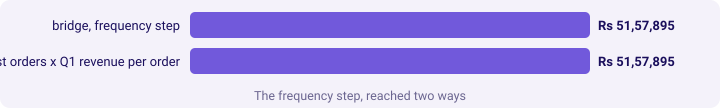

In [12]:
lost_orders = orders["Q1"] - orders["Q2"]
route_two = -lost_orders * v1
kit.bars([("bridge, frequency step", round(-move_frequency)), ("28 lost orders x Q1 revenue per order", round(-route_two))],
         fmt=kit.rupees, title="The frequency step, reached two ways")
kit.check("28 orders were lost between the quarters", lost_orders == 28)
kit.check("both routes put the frequency step at Rs 51,57,895", round(route_two) == round(move_frequency) == -5157895,
          kit.rupees(round(route_two)))

**When to switch.** The direct count works because customers did not move; when customers change too,
the lost orders mix both branches, and only the bridge separates them. The escalated case this
afternoon meets exactly that.

> **Kavya's review.** "Meera asked two questions and you answered both with a count: customers held
> at 69, and the ones we have bought less often. Put the bridge in front of her with its order
> written beside it, and do not call the rise in order value good news until you know where it came
> from."

### In the interview

**[F] Revenue fell 11 percent; how do you split the change between customers, frequency and order
value?** "I write revenue as customers times orders per customer times revenue per order and compute
each leaf in both periods. The ratios multiply back to the revenue ratio, which proves the leaves are
consistent. To put rupees on each, I change one leaf at a time in the tree's order, holding the
others at the earlier period, so the moves add exactly to the total. On Kalpa's quarters that gave
customers nothing, frequency minus Rs 51,57,895 and order value plus Rs 28,57,895. I say that the
split depends on the order, and I keep the order fixed across reports." The interviewer is listening
for the multiplicative check and for rupees in place of percentages that do not add.

**[S] Why is a rate without a denominator meaningless?** "Because a rate is a count divided by
something over a window, and changing either of the other two changes the number. Orders per
customer of 1.25 means one thing over 69 customers in a quarter and another over 50 customers with a
delivered order. When someone quotes a rate, I ask what was counted, what it was divided by and over
which dates." The interviewer is listening for all three parts.

**[S] A field is missing on some records; do you fill it with zero?** "Only if zero is what missing
means, and someone has written down why. Usually missing means not recorded, which is unknown.
Filling with zero makes a total into a floor, and if the blank share changes between periods it
manufactures a trend. So I count the blanks, report them separately, compute on the recorded rows
and bound what the unknowns could do." The interviewer is listening for "unknown", the count of
blanks, and a bound.

**The design question. Which way do you split a revenue change for a CEO, and when would you
change it?** "A bridge in the tree's order, with the order written beside it, because it adds
exactly and a CEO can follow it. On Kalpa's quarters the order moves frequency's charge between
Rs 51.6 lakh and Rs 60.9 lakh and never changes which branch is guilty. If the split is rebuilt
monthly by someone else, I switch to the symmetric split so nobody argues about order." The
interviewer is listening for a reason and the fact that would switch it.

### Depth: the order of the bridge, with three branches moving

With three branches moving at once, a sequential bridge has six possible orders, and the symmetric
split still gives one answer, because the logarithms of the three ratios add exactly to the logarithm
of the revenue ratio (B. W. Ang, "The LMDI approach to decomposition analysis: a practical guide",
Energy Policy, 2005, checked through Crossref 29 Sep 2026). Try it: add a customers term to the
symmetric code in the sizing cell and check that the three moves still sum to the fall.

References for the chapter:

- Python docs, built-in types, `dict.get`: https://docs.python.org/3/library/stdtypes.html (verified 29 Sep 2026)
- Corey Schafer, "Python Tutorial: Using Try/Except Blocks for Error Handling": https://www.youtube.com/watch?v=NIWwJbo-9_8 (verified 29 Sep 2026)

In [13]:
kit.check_summary()
print("Next: chapter 3, which segment carries the fall in orders per customer.")

Next: chapter 3, which segment carries the fall in orders per customer.
